# Forecasting robot position using joint assimilation of high-accuracy GPS and yaw data (with gaps) and low-accuracy GPS data (without gaps). Linear Kalman filter.

## Roman Branovets, Skoltech, 2025

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt, sin, cos

**Problem formulation**

A car-like robot departed a site at 10:00:00 and reached position P after 25 seconds. At exactly
10:00:25, a warning indicated that the robot's battery would deplete in 10 seconds. Given that the
robot receives specific commands to rotate its wheels, can it reach the base in time to recharge?
The GPS coordinates of the base are (213,229) meters.

### Background

**Motion model**

System equations:

$$
x_i = x_{i-1} + V_{i-1} \cos(\gamma_{i-1})  dt + w_i^x
$$

$$
y_i = y_{i-1} + V_{i-1} \sin(\gamma_{i-1})  dt + w_i^y
$$

$$
\gamma_i = \gamma_i + w_{i-1}  dt + w_i^\gamma
$$

**Explanation:**
- $V$ and $w$ represent the linear and angular velocities (control variables) available in `Control.txt`
- Time step between measurements: $dt = 1s$
- Terms $w_i^x$, $w_i^y$, $w_i^\gamma$ represent normally distributed unbiased noise with the following variances:
  $$
  \sigma_{w^x}^2 = 0.02^2, \quad \sigma_{w^y}^2 = 0.02^2, \quad \sigma_{w^\gamma}^2 = 0.001^2
  $$

**State-Space Model**

State Vector

The state of the car-like robot at time $i$ is characterized by its position $x_i, y_i$ and yaw angle $y_i$. The state vector is defined as follows:

$$
X_i = \begin{vmatrix} x_i \\ y_i \\ y_i \end{vmatrix}
$$


The current model can be represented in state space as follows:

State Equation

$$
X_{t+1} = \Phi_{t+1,i} X_t + B_{t+1,i} u_i + W_i
$$

Where:

- Transition matrix $\Phi_{i+1,i} = \begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{bmatrix}$
- Control matrix $B_{i+1,i} = \begin{bmatrix} \cos(\gamma_{i-1}) dt & 0 \\ \sin(\gamma_{i-1}) dt & 0 \\ 0 & dt \end{bmatrix}$
- Control variables $u_i = \begin{vmatrix} V_i \\ w_i \end{vmatrix}$

The covariance matrix of the state noise $Q$ is composed of the diagonal elements of $\sigma_w^2 x$, $\sigma_w^2 y$, and $\sigma_w^2 \gamma$.

Measurement Equation

$$
z_i = H_i X_i + \eta_i
$$

Where $z_i$ is a measurement vector.

### Scenario 1. Construct the Linear Kalman filter using the dataset of GPS measurements from a relatively low-accuracy sensor readings from a relatively low accuracy sensor, are available every second over a 25-second interval.

**Measurement Vector**

In the first scenario, where measurements from 'GPS_low.txt' are used in the filter, the measurement vector $z_i$ consists of two variables: the GPS measurements of position $x_i$ and $y_i$:

$$
z_i = \begin{vmatrix} x_i^m \\ y_i^m \end{vmatrix}
$$

From prior information, we know that the variance of measurement noise for the GPS data is $\sigma_{\eta^x}^2 = 20^2$ and $\sigma_{\eta^y}^2 = 20^2$. Therefore, the covariance matrix of the measurement noise $R$ consists of the diagonal elements of these variances.

**Prediction Step of the Recurrent Kalman Filter Algorithm**

Note that since there is control input for the robot in this case, the prediction equation must account for it by incorporating the control input into the prediction.

$$
X_{i,i-1} = \Phi_{i,i-1} X_{i-1,i-1} + B_{i,i-1} u_{i-1}
$$

In [74]:
#load data from files
gps_low = np.loadtxt("GPS_low.txt")
control = np.loadtxt("Control.txt")
gps_low = gps_low.reshape(25, 2, 1)
control = control.reshape(35, 2, 1)

Let's define the parameters of this system

In [75]:
N = 25
M = 10
dt = 1
sigma_x = 0.02**2
sigma_y = 0.02**2
sigma_gamma = 0.001**2
sigma_meas_x = 20**2
sigma_meas_y = 20**2
#transition matrix
fi=np.matrix([[1, 0, 0],[0, 1, 0], [0, 0, 1]])
#covariance matrix of state noise
Q = np.matrix([[sigma_x, 0, 0], [0, sigma_y, 0], [0, 0, sigma_gamma]])
#observation matrix
h = np.matrix([[1, 0, 0], [0, 1, 0]])
#covariance matrix of the measurement noise
R = np.matrix([[sigma_meas_x, 0], [0, sigma_meas_y]])
#state vector
X = np.zeros((N + M, 3, 1))
#control matrix
b = np.zeros((N + M, 3, 2))
b[0] = np.matrix([[0, 0], [0, 0], [0, 0]])
#Initial filtered estimate
X[0]=np.matrix([[0], [0], [0]])
#Filtration error covariance matrix
P=np.zeros((N + M, 3, 3))
P[0]=np.matrix([[10000, 0, 0], [0, 10000, 0], [0, 0, 10000]])
K = np.ones((N, 3, 2))
for i in range(1, N):
    #step of prediction
    #control matrix
    b[i] = np.matrix([[cos(X[i-1, 2, 0])*dt, 0], [sin(X[i-1, 2, 0])*dt, 0], [0, dt]])
    X[i]=fi @ X[i-1] + b[i] @ control[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h@P[i]@h.T + R
    K[i]=(P[i]@h.T)@np.linalg.inv(E)
    X[i]=X[i]+K[i]*(gps_low[i]-h@X[i])
    P[i]=(np.identity(3)-K[i]@h)@P[i]
#performing prediction for 10 steps
for j in range(N, N+M):
    #control matrix
    b[j] = np.matrix([[cos(X[j-1, 2, 0])*dt, 0], [sin(X[j-1, 2, 0])*dt, 0], [0, dt]])
    X[j] = fi @ X[j-1] + b[j] @ control[j-1]
    P[j]=(fi @ P[j-1] @ fi.T) + Q

Let's plot meausrement, filtered and predicted estimates

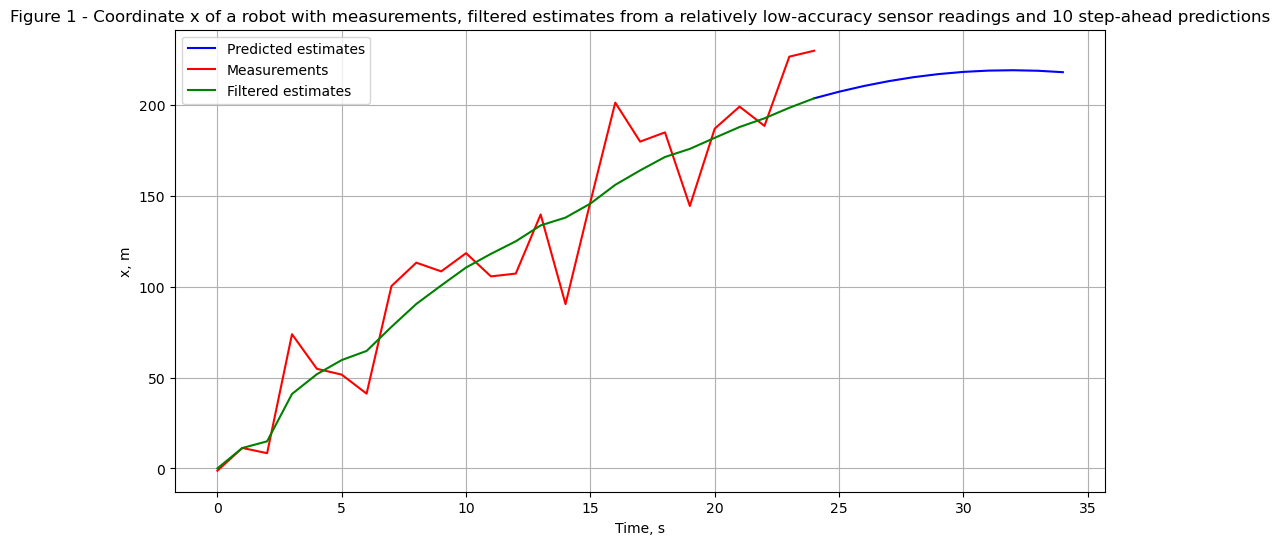

In [76]:
#Plots of measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(24, 35), X[N-1:, 0, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 0, 0], color='red',  label='Measurements')
plt.plot(X[:N,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 1 - Coordinate x of a robot with measurements, filtered estimates from a relatively low-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('Time, s')
plt.ylabel('x, m')
plt.legend()
plt.grid()
plt.show()

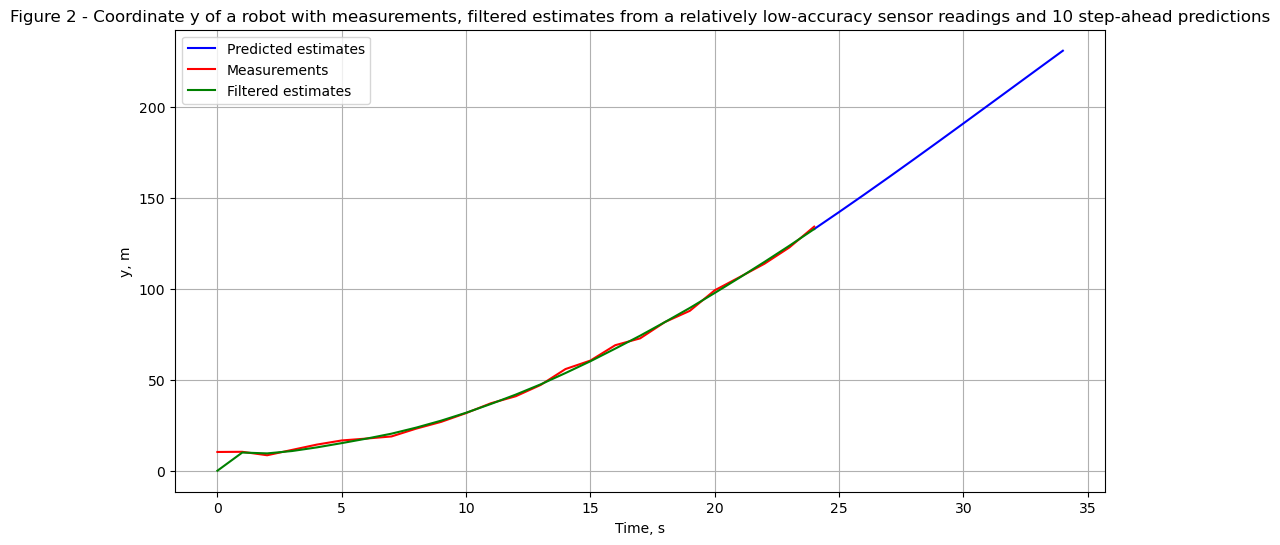

In [77]:
#Plots of measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(24, 35), X[N-1:, 1, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 1, 0], color='red',  label='Measurements')
plt.plot(X[:N,1,0], color='green',  label='Filtered estimates')
plt.title('Figure 2 - Coordinate y of a robot with measurements, filtered estimates from a relatively low-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('Time, s')
plt.ylabel('y, m')
plt.legend()
plt.grid()
plt.show()

Let's plot calculated errors of the filtered estimates and calculated error of prediction

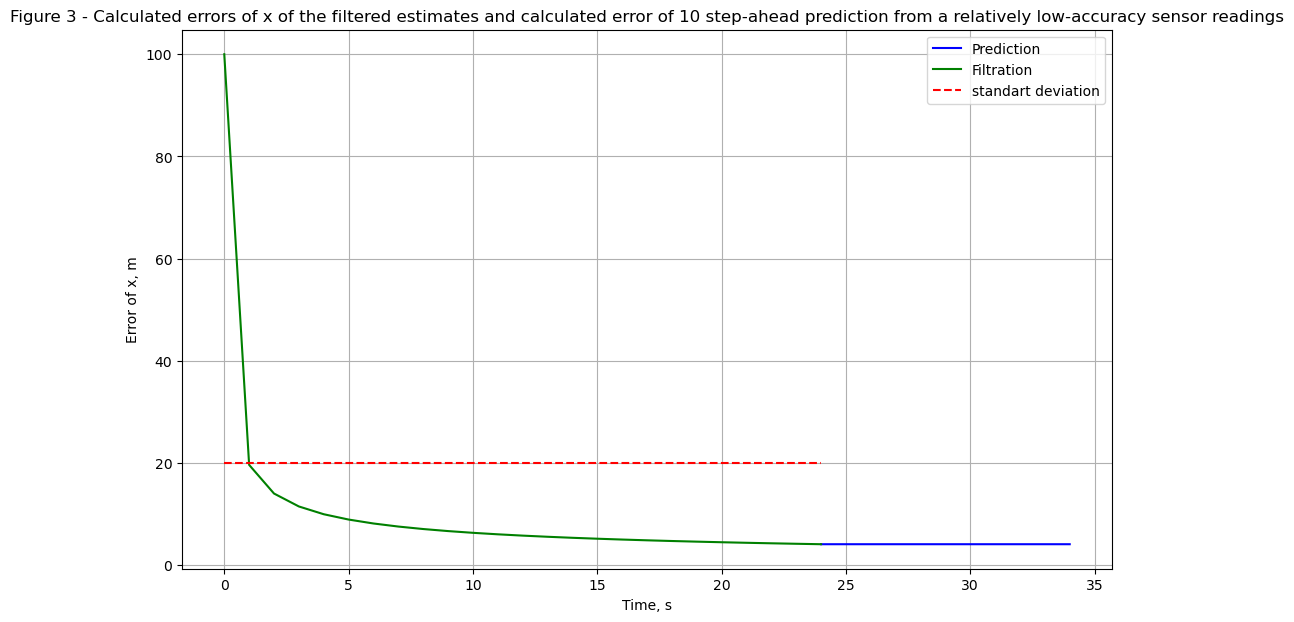

In [78]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 0, 0]), color="blue",  label='Prediction')
plt.plot(np.sqrt(P[:N,0,0]), color='green',  label='Filtration')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x), 25), 'r--',  label='standart deviation')
plt.title('Figure 3 - Calculated errors of x of the filtered estimates and calculated error of 10 step-ahead prediction from a relatively low-accuracy sensor readings')
plt.xlabel('Time, s')
plt.ylabel('Error of x, m')
plt.legend()
plt.grid()
plt.show()

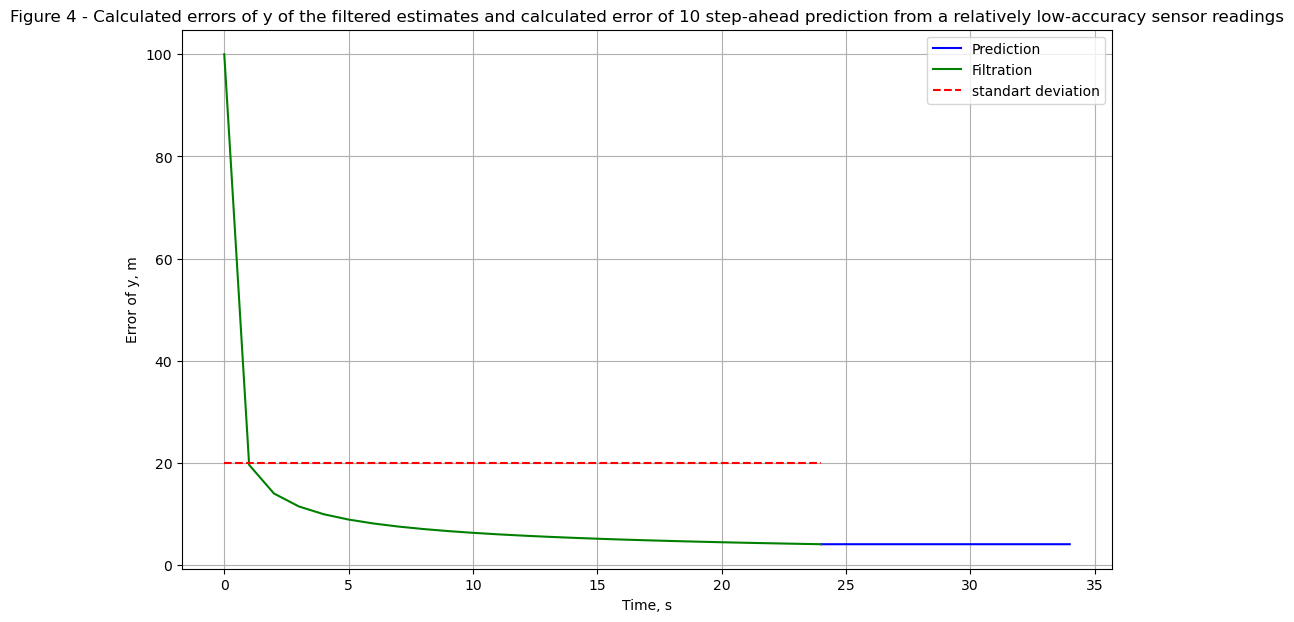

In [79]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 1, 1]), color="blue",  label='Prediction')
plt.plot(np.sqrt(P[:N,1,1]), color='green',  label='Filtration')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_y), 25), 'r--',  label='standart deviation')
plt.title('Figure 4 - Calculated errors of y of the filtered estimates and calculated error of 10 step-ahead prediction from a relatively low-accuracy sensor readings')
plt.xlabel('Time, s')
plt.ylabel('Error of y, m')
plt.legend()
plt.grid()
plt.show()

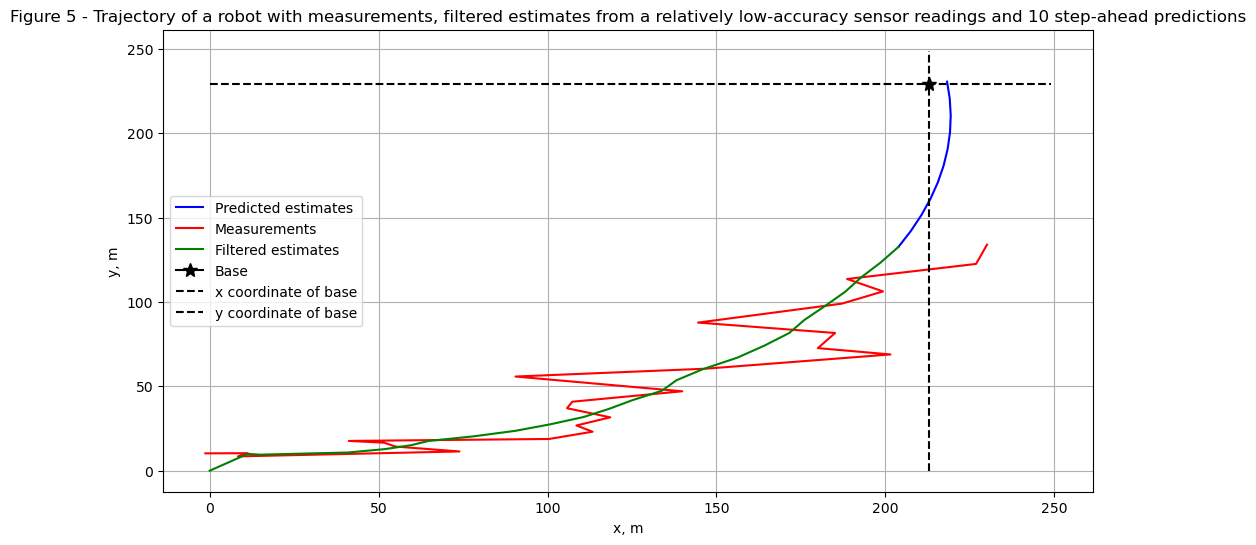

In [80]:
#Plot of trajectory with measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(X[N-1:, 0, 0], X[N-1:, 1, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 0, 0], gps_low[:, 1, 0], color='red',  label='Measurements')
plt.plot(X[:N,0,0], X[:N,1,0], color='green',  label='Filtered estimates')
plt.plot(213, 229, color='black', marker='*', markersize=10, label='Base')
plt.plot(np.arange(250), np.repeat(229, 250), color='black', linestyle='--', label='x coordinate of base')
plt.plot(np.repeat(213, 250) ,np.arange(250), color='black', linestyle='--', label='y coordinate of base')
plt.title('Figure 5 - Trajectory of a robot with measurements, filtered estimates from a relatively low-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('x, m')
plt.ylabel('y, m')
plt.legend()
plt.grid()
plt.show()
P_low = P
X_low = X

Thus, the robot will not return to base in 10 seconds based on our forecast. We see that the robot reaches the required x and y, but it does not return to the desired point. We can also note that the Kalman filter filters measurements well, the calculated error of filtration decreases and is less than the standard deviation of measurement errors. We also see that the calculated error of prediction is growing extremely slowly 10 steps ahead due to the low state noise.

### Scenario 2. Develop a filter that integrates both datasets: using joint assimilation of high-accuracy GPS and yaw data (with gaps) and low-accuracy GPS data (without gaps)

In [81]:
#load data from file
gps_high = np.loadtxt('GPS_yaw_high.txt')
gps_high = gps_high.reshape(25, 3, 1)
#Kalman filter algorithm
N = 25
M = 10
dt = 1
sigma_x = 0.02**2
sigma_y = 0.02**2
sigma_gamma = 0.001**2
sigma_meas_x_low = 20**2
sigma_meas_y_low = 20**2
sigma_meas_x_high = 1**2
sigma_meas_y_high = 1**2
sigma_meas_gamma_high = 0.1**2
#transition matrix
fi=np.matrix([[1, 0, 0],[0, 1, 0], [0, 0, 1]])
#covariance matrix of state noise
Q = np.matrix([[sigma_x, 0, 0], [0, sigma_y, 0], [0, 0, sigma_gamma]])
#observation matrix
h_low = np.matrix([[1, 0, 0], [0, 1, 0]])
h_high = np.matrix([[1, 0, 0], [0, 1, 0], [0, 0, 0]])
#covariance matrix of the measurement noise
R_low = np.matrix([[sigma_meas_x_low, 0], [0, sigma_meas_y_low]])
R_high = np.matrix([[sigma_meas_x_high, 0, 0], [0, sigma_meas_y_high, 0], [0, 0, sigma_meas_gamma_high]])
#state vector
X = np.zeros((N + M, 3, 1))
#control matrix
b = np.zeros((N + M, 3, 2))
b[0] = np.matrix([[0, 0], [0, 0], [0, 0]])
#Initial filtered estimate
X[0]=np.matrix([[0], [0], [0]])
#Filtration error covariance matrix
P=np.zeros((N + M, 3, 3))
P[0]=np.matrix([[10000, 0, 0], [0, 10000, 0], [0, 0, 10000]])
K_low = np.ones((N, 3, 2))
K_high = np.ones((N, 3, 3))
for i in range(1, N):
    #step of prediction
    #control matrix
    b[i] = np.matrix([[cos(X[i-1, 2, 0])*dt, 0], [sin(X[i-1, 2, 0])*dt, 0], [0, dt]])
    X[i]=fi @ X[i-1] + b[i] @ control[i-1]
    P[i]=(fi@P[i-1]@fi.T)+Q
    #step of filtration
    E=h_low@P[i]@h_low.T + R_low
    K_low[i]=(P[i]@h_low.T)@np.linalg.inv(E)
    X[i]=X[i]+K_low[i]*(gps_low[i]-h_low@X[i])
    P[i]=(np.identity(3)-K_low[i]@h_low)@P[i]
    if not np.all(np.isnan(gps_high[i])):
        E=h_high@P[i]@h_high.T + R_high
        K_high[i]=(P[i]@h_high.T)@np.linalg.inv(E)
        X[i]=X[i]+K_high[i]*(gps_high[i]-h_high@X[i])
        P[i]=(np.identity(3)-K_high[i]@h_high)@P[i]
#performing prediction for 10 steps
for j in range(N, N+M):
    #control matrix
    b[j] = np.matrix([[cos(X[j-1, 2, 0])*dt, 0], [sin(X[j-1, 2, 0])*dt, 0], [0, dt]])
    X[j] = fi @ X[j-1] + b[j] @ control[j-1]
    P[j]=(fi @ P[j-1] @ fi.T) + Q

Let's plot meausrement, filtered and predicted estimates

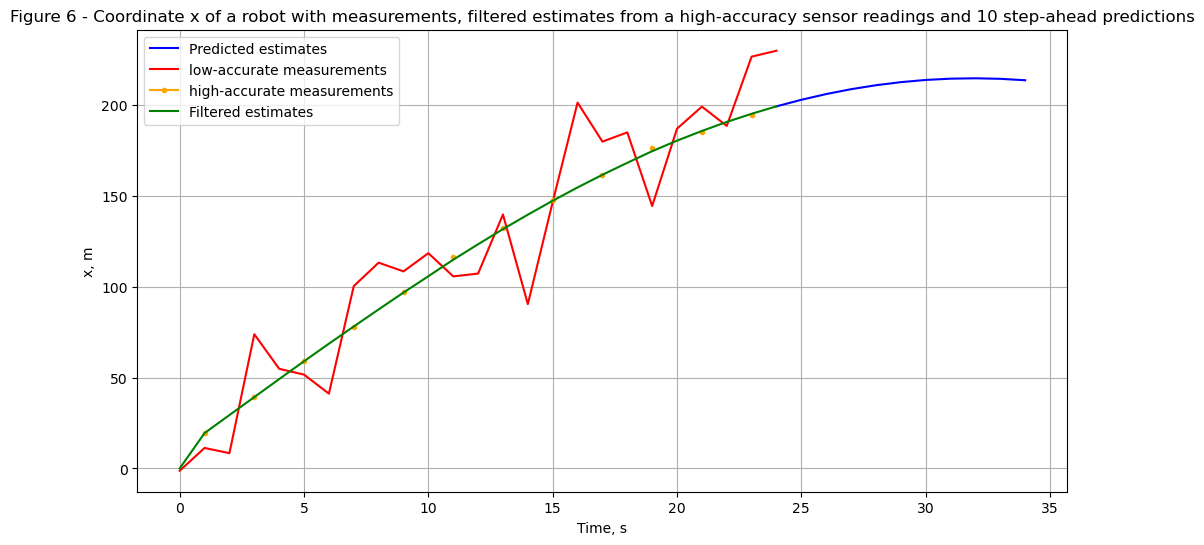

In [82]:
#Plots of measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(24, 35), X[N-1:, 0, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 0, 0], color='red',  label='low-accurate measurements')
plt.plot(gps_high[:, 0, 0], color='orange', marker='.', label='high-accurate measurements')
plt.plot(X[:N,0,0], color='green',  label='Filtered estimates')
plt.title('Figure 6 - Coordinate x of a robot with measurements, filtered estimates from a high-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('Time, s')
plt.ylabel('x, m')
plt.legend()
plt.grid()
plt.show()

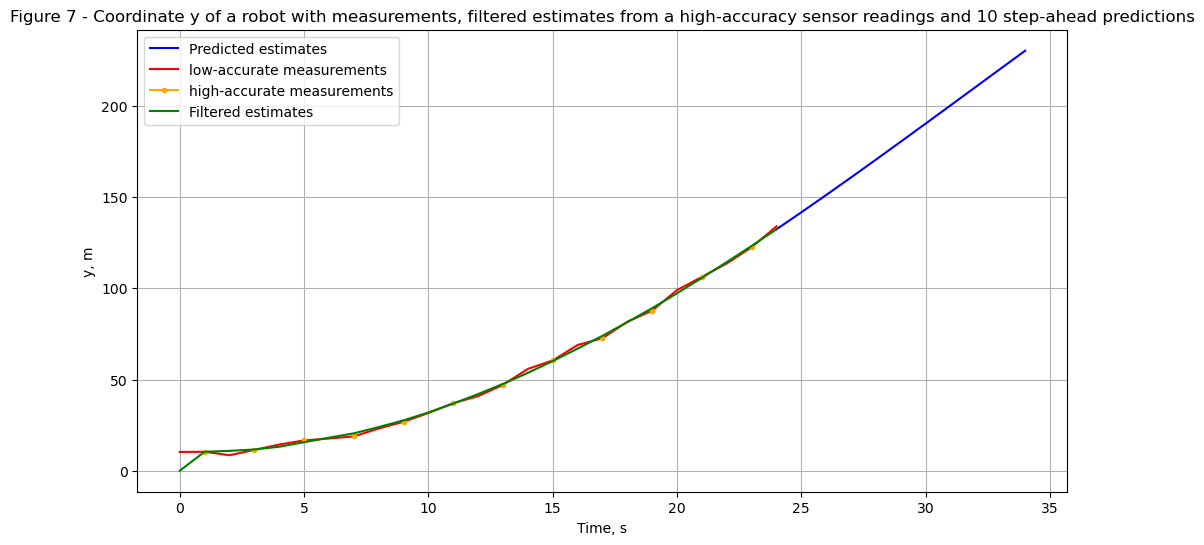

In [83]:
#Plots of measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(np.arange(24, 35), X[N-1:, 1, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 1, 0], color='red',  label='low-accurate measurements')
plt.plot(gps_high[:, 1, 0], color='orange', marker='.', label='high-accurate measurements')
plt.plot(X[:N,1,0], color='green',  label='Filtered estimates')
plt.title('Figure 7 - Coordinate y of a robot with measurements, filtered estimates from a high-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('Time, s')
plt.ylabel('y, m')
plt.legend()
plt.grid()
plt.show()

Let's plot calculated errors of the filtered estimates and calculated error of prediction

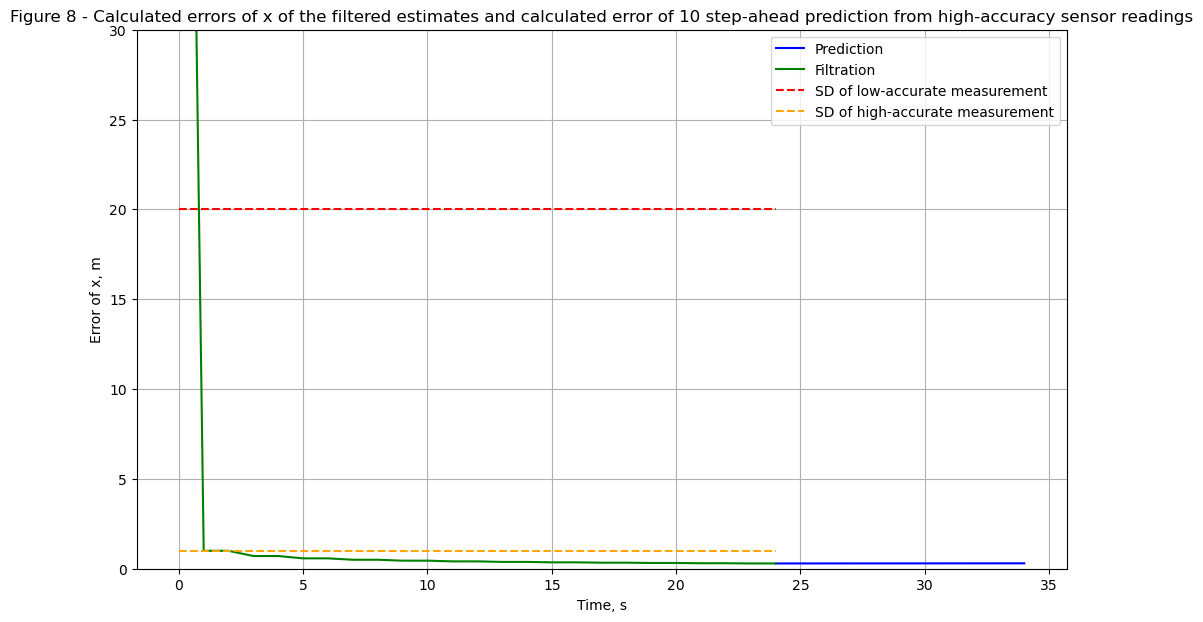

In [84]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 0, 0]), color="blue",  label='Prediction')
plt.plot(np.sqrt(P[:N,0,0]), color='green',  label='Filtration')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_low), 25), 'r--',  label='SD of low-accurate measurement')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_high), 25), color='orange', linestyle='--',  label='SD of high-accurate measurement')
plt.title('Figure 8 - Calculated errors of x of the filtered estimates and calculated error of 10 step-ahead prediction from high-accuracy sensor readings')
plt.xlabel('Time, s')
plt.ylabel('Error of x, m')
plt.legend()
plt.ylim(0,30)
plt.grid()
plt.show()

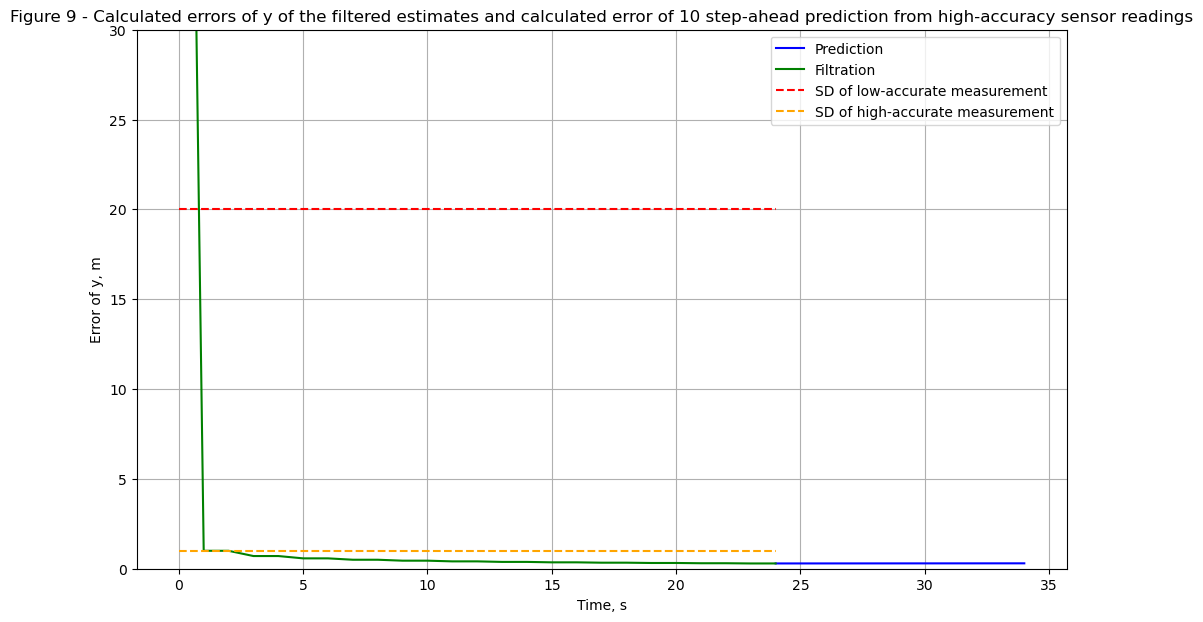

In [85]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 1, 1]), color="blue",  label='Prediction')
plt.plot(np.sqrt(P[:N,1,1]), color='green',  label='Filtration')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_y_low), 25), 'r--',  label='SD of low-accurate measurement')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_y_high), 25), color='orange', linestyle='--',  label='SD of high-accurate measurement')
plt.title('Figure 9 - Calculated errors of y of the filtered estimates and calculated error of 10 step-ahead prediction from high-accuracy sensor readings')
plt.xlabel('Time, s')
plt.ylabel('Error of y, m')
plt.legend()
plt.ylim(0,30)
plt.grid()
plt.show()

The error of filtering and forecasting decreased, which means that the accuracy of estimates increased. In addition, the calculated error does not exceed the standard deviation of the measurement errors of the high-accuracy sensor throughout the entire observation and prediction.

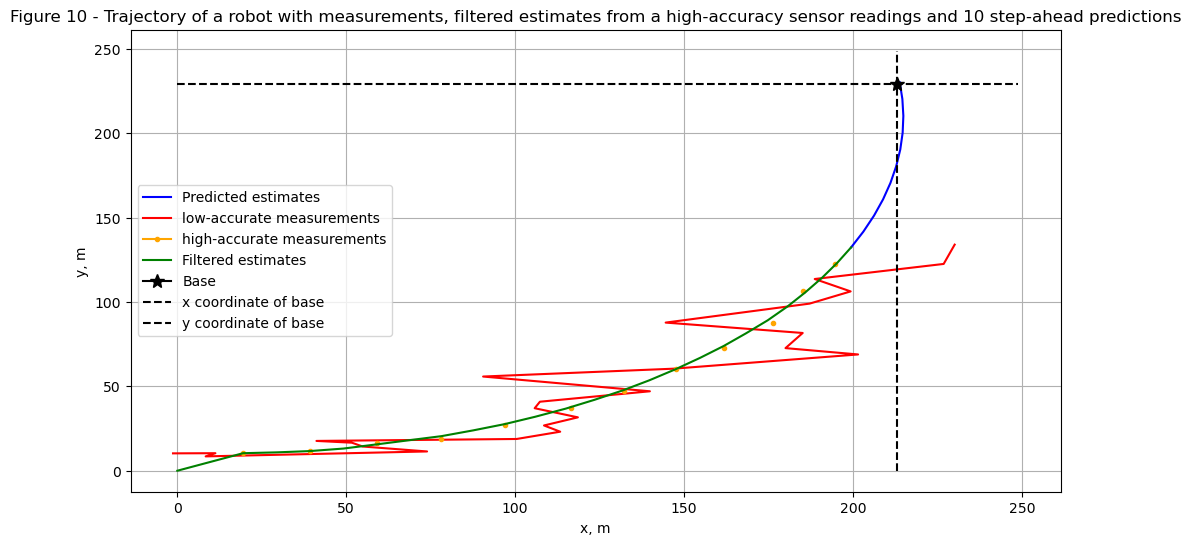

In [90]:
#Plot of trajectory with measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(X[N-1:, 0, 0], X[N-1:, 1, 0], color="blue",  label='Predicted estimates')
plt.plot(gps_low[:, 0, 0], gps_low[:, 1, 0], color='red',  label='low-accurate measurements')
plt.plot(gps_high[:, 0, 0], gps_high[:, 1, 0], color='orange', marker='.', label='high-accurate measurements')
plt.plot(X[:N,0,0], X[:N,1,0], color='green',  label='Filtered estimates')
plt.plot(213, 229, color='black', marker='*', markersize=10, label='Base')
plt.plot(np.arange(250), np.repeat(229, 250), color='black', linestyle='--', label='x coordinate of base')
plt.plot(np.repeat(213, 250) ,np.arange(250), color='black', linestyle='--', label='y coordinate of base')
plt.title('Figure 10 - Trajectory of a robot with measurements, filtered estimates from a high-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('x, m')
plt.ylabel('y, m')
plt.legend()
plt.grid()
plt.show()

We see that the robot has returned to base. We can say that the calculated error decreased and this decrease that allowed us to obtain a more accurate forecast. Due to the fact that we have more accurate measurements and measure all three coordinates, we can make a more accurate forecast.

Let's compare errors of filtration and predictions for 10 steps ahead

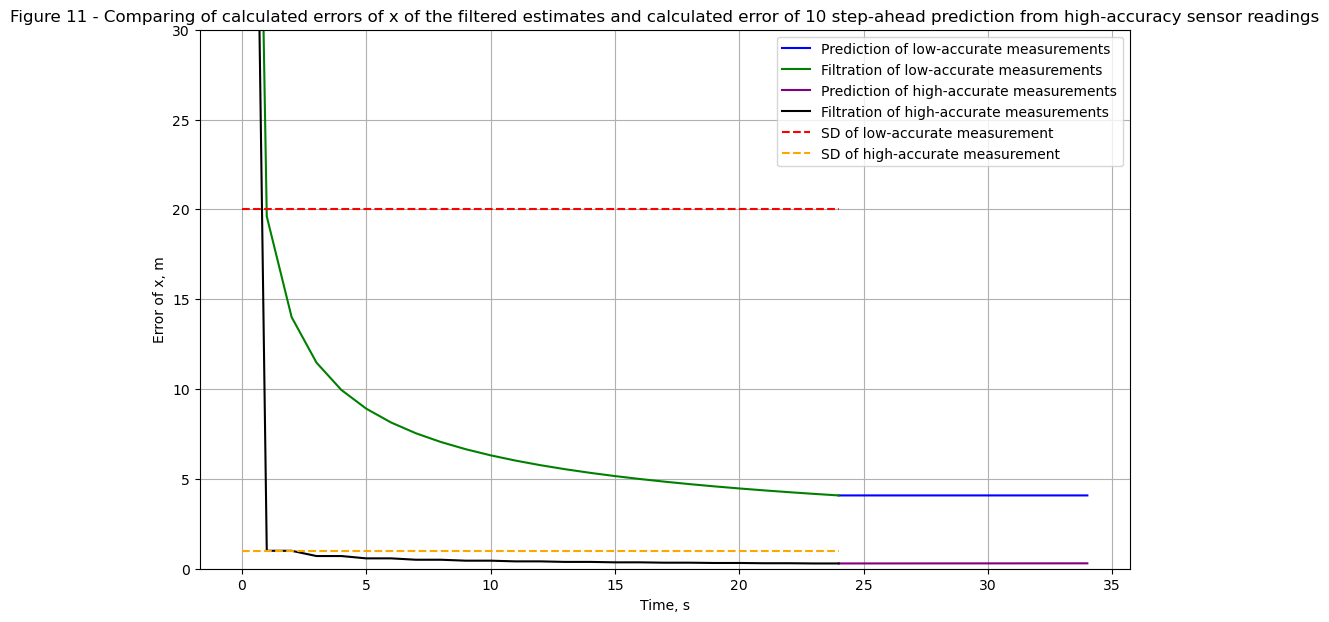

In [87]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P_low[N-1:, 0, 0]), color="blue",  label='Prediction of low-accurate measurements')
plt.plot(np.sqrt(P_low[:N,0,0]), color='green',  label='Filtration of low-accurate measurements')
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 0, 0]), color="purple",  label='Prediction of high-accurate measurements')
plt.plot(np.sqrt(P[:N,0,0]), color='black',  label='Filtration of high-accurate measurements')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_low), 25), 'r--',  label='SD of low-accurate measurement')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_high), 25), color='orange', linestyle='--',  label='SD of high-accurate measurement')
plt.title('Figure 11 - Comparing of calculated errors of x of the filtered estimates and calculated error of 10 step-ahead prediction')
plt.xlabel('Time, s')
plt.ylabel('Error of x, m')
plt.legend()
plt.ylim(0,30)
plt.grid()
plt.show()

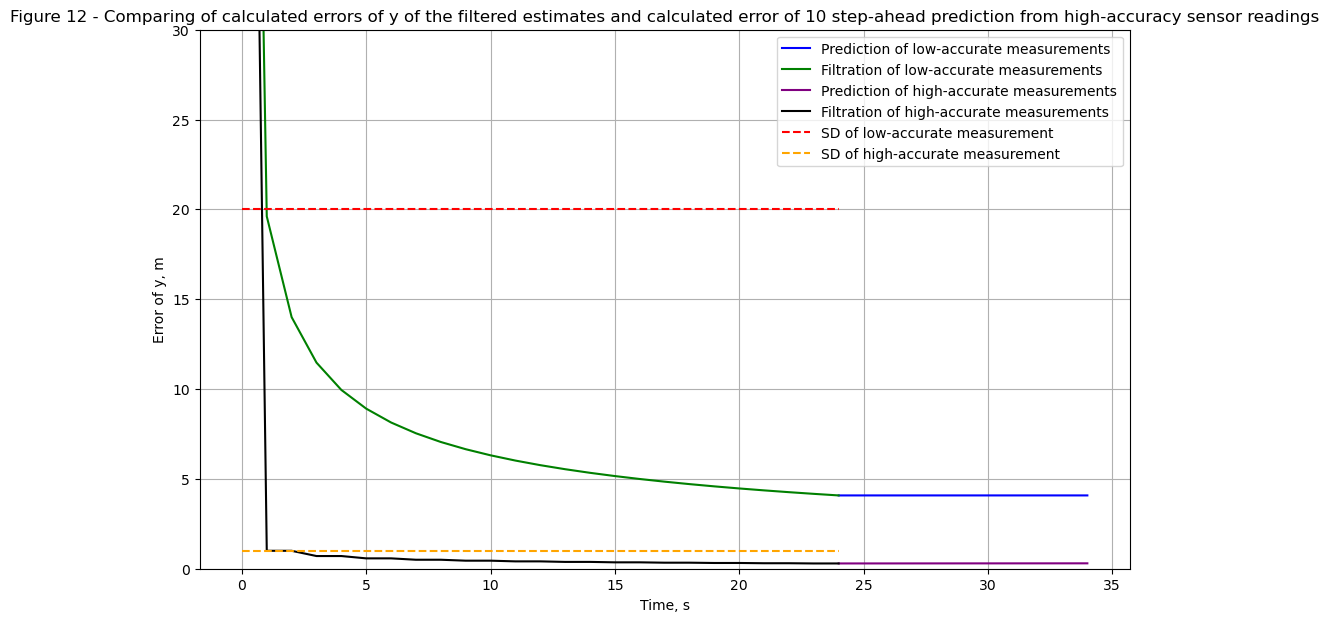

In [88]:
#plot calculated errors of the filtered estimates and calculated error of prediction
plt.figure(figsize=(12, 7))
plt.plot(np.arange(24, 35), np.sqrt(P_low[N-1:, 1, 1]), color="blue",  label='Prediction of low-accurate measurements')
plt.plot(np.sqrt(P_low[:N,1,1]), color='green',  label='Filtration of low-accurate measurements')
plt.plot(np.arange(24, 35), np.sqrt(P[N-1:, 1, 1]), color="purple",  label='Prediction of high-accurate measurements')
plt.plot(np.sqrt(P[:N,1,1]), color='black',  label='Filtration of high-accurate measurements')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_low), 25), 'r--',  label='SD of low-accurate measurement')
plt.plot(np.arange(25), np.repeat(sqrt(sigma_meas_x_high), 25), color='orange', linestyle='--',  label='SD of high-accurate measurement')
plt.title('Figure 12 - Comparing of calculated errors of y of the filtered estimates and calculated error of 10 step-ahead prediction')
plt.xlabel('Time, s')
plt.ylabel('Error of y, m')
plt.legend()
plt.ylim(0,30)
plt.grid()
plt.show()

As we can see, calculated errors decreased significantly. Because of we receive high precision data,the uncertainty, and therefore the error, decrease ssignificantly faster than with data with a higher measurement error. Moreover, due to the relatively low state noise, the calculated error does not increaseas rapidly during periods when we do not have a measurement.

Let's compare trajectories in different cases

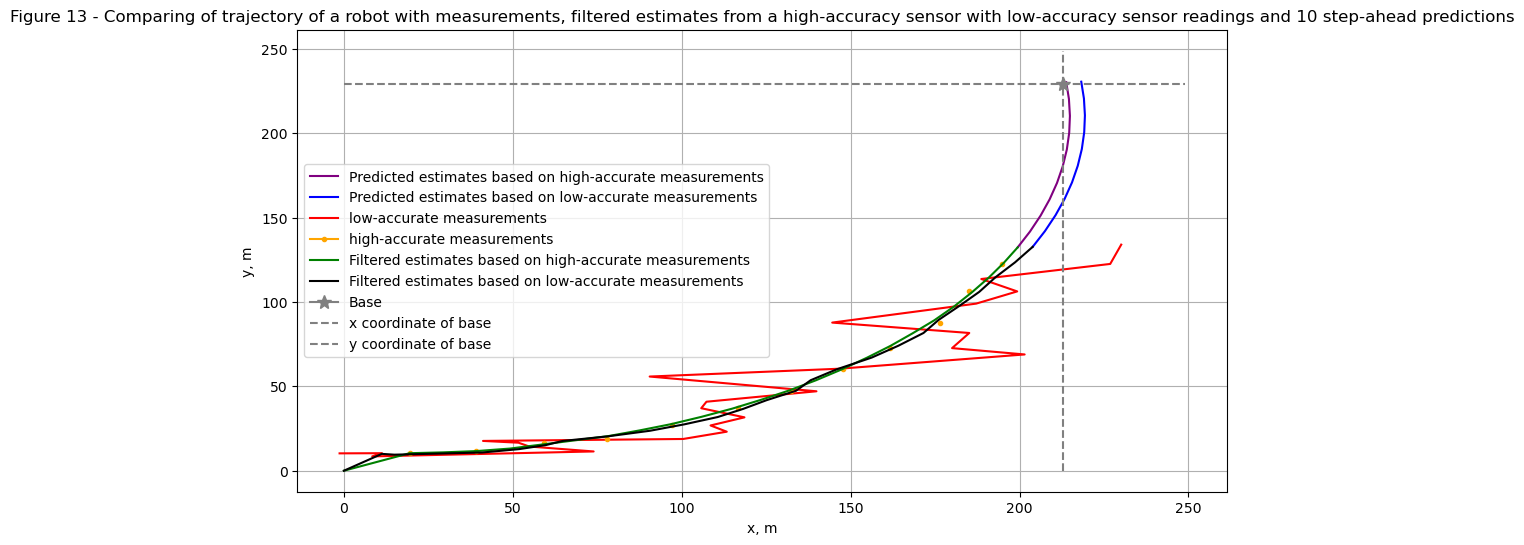

In [92]:
#Plot of trajectory with measurements, filtered and predicted estimates
plt.figure(figsize=(12, 6))
plt.plot(X[N-1:, 0, 0], X[N-1:, 1, 0], color="purple",  label='Predicted estimates based on high-accurate measurements')
plt.plot(X_low[N-1:, 0, 0], X_low[N-1:, 1, 0], color="blue",  label='Predicted estimates based on low-accurate measurements')
plt.plot(gps_low[:, 0, 0], gps_low[:, 1, 0], color='red',  label='low-accurate measurements')
plt.plot(gps_high[:, 0, 0], gps_high[:, 1, 0], color='orange', marker='.', label='high-accurate measurements')
plt.plot(X[:N,0,0], X[:N,1,0], color='green',  label='Filtered estimates based on high-accurate measurements')
plt.plot(X_low[:N,0,0], X_low[:N,1,0], color='black',  label='Filtered estimates based on low-accurate measurements')
plt.plot(213, 229, color='gray', marker='*', markersize=10, label='Base')
plt.plot(np.arange(250), np.repeat(229, 250), color='gray', linestyle='--', label='x coordinate of base')
plt.plot(np.repeat(213, 250) ,np.arange(250), color='gray', linestyle='--', label='y coordinate of base')
plt.title('Figure 13 - Comparing of trajectory of a robot with measurements, filtered estimates from a high-accuracy sensor with low-accuracy sensor readings and 10 step-ahead predictions')
plt.xlabel('x, m')
plt.ylabel('y, m')
plt.legend()
plt.grid()
plt.show()

Because of we obtained more accurate filtered estimates, the accuracy of our predictions increased and decreased slightly over the prediction interval.

**Conclusion**

Even with gaps, high -precision measurements dramatically improve the quality of
system condition assessment, especially when they contain information about
additional state parameters (yaw angle) . Based on the second scenario, the robot
can return to base!
The Kalman filter is the optimal linear estimator for our task . But it's worth
remembering the risks .\
Risks :
1. Our model does not take into account nonlinearities that may
arise in the data .
2. Lack of processing of measurement bias .
3. Lack of compensation for missing measurements .
4. Lack of analysis of the correlation between process noise and
measurement noise .